# Check the BDT to separate signal from various backgound types

### Setting up the data and tools

In [1]:
# Importing the notebook with common setup 
%run 'setup_mc.ipynb'

Welcome to JupyROOT 6.28/00


Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903000") to load datasets
Invoke (root_datasets, pandas_datasets) = load_data(inclmc_type="23903003") to load dataset for double charm
Invoke  df_signal_23903000 = load_signal_from_inclMC() to load signal from 23903000 Inclusive MC
or
Invoke  df_signal = load_signal_all()
Invoke  df_background = load_background_category(category)


In [2]:
import xgboost as xgb
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.utils import shuffle

## Loading the BDTs

In [3]:
#model = xgb.XGBClassifier()
#model.load_model("../model_18.json")
import joblib
import os
# bdt_18 = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_18_200.pkl")
# bdt_19 = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_19_200.pkl")
# bdt_20 = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_20_200.pkl")
# bdt_all = joblib.load("../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/pidgen_merged/xgboost/bdt_all_200.pkl")

OUTPUT_DIR= "../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/final/train_bdt/output"
print(f"Loading BDTs from {OUTPUT_DIR}")
bdt_18 = joblib.load(os.path.join(OUTPUT_DIR, "categbdt_18_150.pkl"))
bdt_19 = joblib.load(os.path.join(OUTPUT_DIR, "categbdt_19_150.pkl"))
bdt_20 = joblib.load(os.path.join(OUTPUT_DIR, "categbdt_20_150.pkl"))
bdt_all = joblib.load("../bdtdblcharm_150_3_0.04.pkl")


Loading BDTs from ../eoslhcb.cern.ch/eos/lhcb/wg/semileptonic/RDsHad/AP/final/train_bdt/output


## Loading the data

In [4]:
dfall = load_complete_df()
dfall.shape

(649799, 36)

In [5]:
# We check the BDTs on eeventIndex 1 as they were traineds on eventIndex 0
df = dfall.query("eventIndex == 1")
from sklearn.model_selection import train_test_split
valid, df = train_test_split(df, test_size=0.5)
df.shape

(162408, 36)

In [6]:
# c = mygroupby(dfall, 'category')
# c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
# c

## Checking the constitution of the sample

In [7]:
c = mygroupby(df, 'category')
c['name'] = c.apply(lambda row: categories[f"{row['category']:.4g}"], axis=1)
c

,category,count,Percentage,cumulative %,name
0,18,34715,21.375179,21.375179,Xc_signal_Ypis_displaced_fromBs_fromDs
1,19,33995,20.931851,42.307029,Xc_signal_Ypis_displaced_fromB0_fromDp
2,14,21969,13.527043,55.834072,Xc_signal_Ypis_diffVertex_doubleCharm_OneFromB
3,20,14512,8.935520,64.769593,Xc_signal_Ypis_displaced_fromBp_fromD0
4,0,13352,8.221270,72.990863,Xc_background
5,7,10791,6.644377,79.635240,Xc_signal_Ypis_nomatch_doubleCharm
6,22,7688,4.733757,84.368997,Xc_signal_Ypis_displaced_fromBs_fromDp
7,23,4322,2.661199,87.030196,Xc_signal_Ypis_displaced_fromBp_fromDp
8,16,3547,2.184006,89.214201,Xc_signal_Ypis_diffVertex_CharmStrange
9,24,3110,1.914930,91.129132,Xc_signal_Ypis_displaced_fromBs_fromTau


## Added columns with the output of the BDTs for categories 18, 19, 20

In [ ]:
#df['category']
#mygroupby(df, 'category')
df = df.copy()
train_columns = [
    "Y_0_40_nc_mult",
    "Y_0_20_cc_mult",
    "Y_0_20_cc_PZ",
    "Y_0_30_nc_PZ",
    "Y_0_40_nc_PZ",
    "min_m2pi",
    "max_m2pi",
    "missing_mass_2",
    "B_BPVVDR",
    "B_M",
    "B_correctedMass",
    "log(abs(PBsn))",
    "log(abs(PBv/B_P))",
    "log(abs(PBvn/B_P))",
    "log(abs((PBsn-PBvn)/PBvn))",
    "log(sqrt(abs(mDs2vn)))",
    "mN2v",
    "log(Y_PE)",
    "BDT_Iso",
    "B_pT_Bdir",
    "Y_BPVVDR",
    "missing_pY_mass",
    "Y_correctedMass",
]
pred = bdt_18.predict_proba(df[train_columns])
df['bdt_18'] = pred[:,1]
pred = bdt_19.predict_proba(df[train_columns])
df['bdt_19'] = pred[:,1]
pred = bdt_20.predict_proba(df[train_columns])
df['bdt_20'] = pred[:,1]
pred = bdt_all.predict_proba(df[train_columns])
df['bdt_all'] = pred[:,1]


In [ ]:
def plot_roc(df, proba_column, desc):
    fpr, tpr, _ = roc_curve(df['category'] == 24, df[proba_column])
    roc_auc = auc(fpr, tpr)
    plt.plot(1 - fpr, tpr, label=f"{desc} AUC:{roc_auc:.3f}")

def plot_all(df, title, filename):
    plt.rcParams["figure.figsize"] = (10,6)
    plt.rcParams.update({'font.size': 12})
    plot_roc(df, 'bdt_all', 'BDT trained whole sample')
    plot_roc(df, 'bdt_18', 'BDT trained to separate signal from $B_s$ to $D_s$ decays')
    plot_roc(df, 'bdt_19', 'BDT trained to separate signal from $B^0$ to $D^+$ decays')
    plot_roc(df, 'bdt_20', 'BDT trained to separate signal from $B^+$ to $D^0$ decays')
    plt.title(f"True positive rate  vs (1 - false positive rate)\n{title} ({len(df.query('category == 24'))} signal candidates/ {len(df.query('category != 24'))} background)")
    plt.legend();
    plt.tight_layout()
    plt.savefig(filename)
    
plot_all(df, "Complete test sample", "roc_sig_vs_all.png")

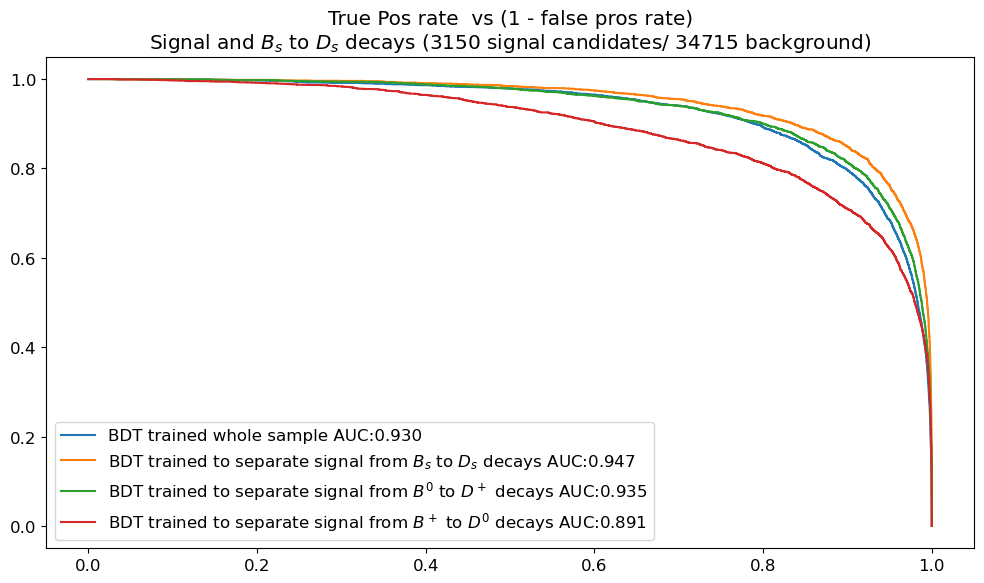

In [41]:
df2 = df[ (df['category'] == 24) | (df['category'] == 18)]
plot_all(df2, "Signal and $B_s$ to $D_s$ decays", "roc_sig_vs_18.png")

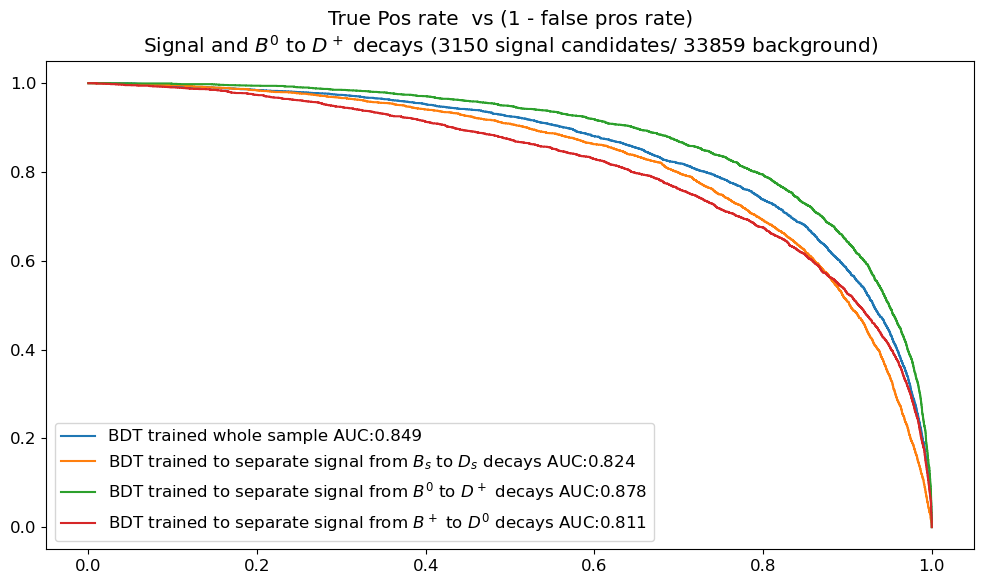

In [42]:
df3 = df[ (df['category'] == 24) | (df['category'] == 19)]
plot_all(df3, "Signal and $B^0$ to $D^+$ decays", "roc_sig_vs_19.png")

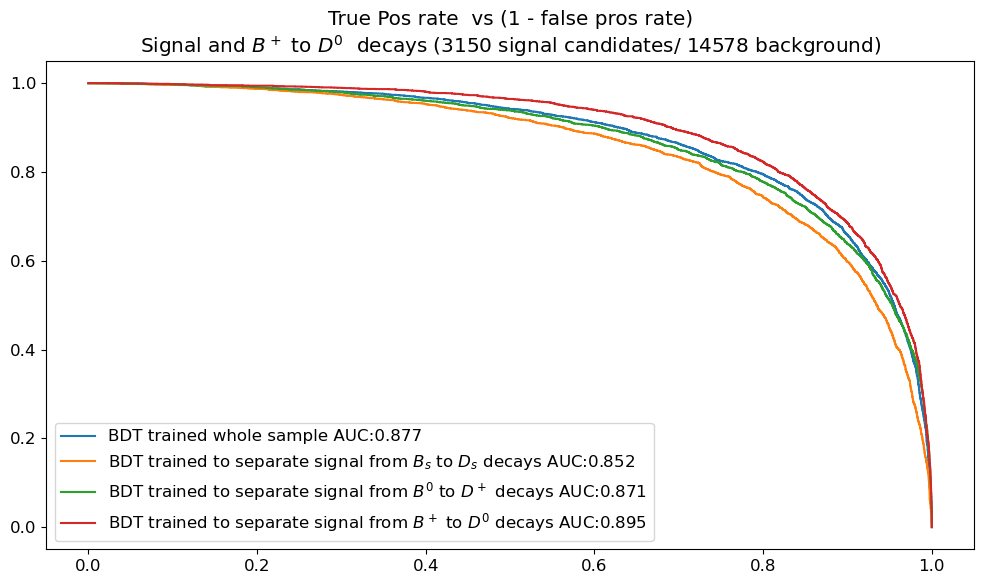

In [43]:
df4 = df[ (df['category'] == 24) | (df['category'] == 20)]
plot_all(df4, "Signal and $B^+$ to $D^0$  decays", "roc_sig_vs_20.png")